# Fit a Delayed Exponential - NGC 337

Using the Dale et al. (2017) photometry, fit the SED of NGC 337 with a basic model that would have been the default model in IDL Lightning.

## Imports

In [2]:
import numpy as np
import h5py
rng = np.random.default_rng()
import astropy.units as u
from astropy.table import Table
from corner import corner
import matplotlib.pyplot as plt
plt.style.use('lightning.plots.style.lightning-serif')
%matplotlib inline

from lightning import Lightning
from lightning.priors import UniformPrior, ConstantPrior

## Initialization

We read in the photometry and information like the distance from a `fits` file and load it into Lightning:

In [3]:
cat = Table.read('../photometry/ngc337_dale17_photometry.fits')

# Housekeeping to load the photometry:
filter_labels = np.array([s.decode().strip() for s in cat['FILTER_LABELS'].data[0]])
fnu_obs = cat['FNU_OBS'].data[0]
fnu_unc = cat['FNU_UNC'].data[0]
dl = cat['LUMIN_DIST'].data[0]

lgh = Lightning(filter_labels, 
              lum_dist=dl, 
              stellar_type='PEGASE-A24',
              SFH_type='Delayed-Exponential',
              atten_type='Modified-Calzetti',
              dust_emission=True,
              model_unc=0.10,
              print_setup_time=True)

lgh.flux_obs = fnu_obs * 1e3
lgh.flux_unc = fnu_unc * 1e3

# We could save the configuration like so:
# lgh.save_pickle('ngc337_config.pkl')

0.204 s elapsed in _get_filters
0.001 s elapsed in _get_wave_obs
2.256 s elapsed in stellar model setup
0.000 s elapsed in dust attenuation model setup
1.353 s elapsed in dust emission model setup
0.000 s elapsed in agn emission model setup
0.000 s elapsed in X-ray model setup
3.813 s elapsed total


Display the parameters and their allowed ranges. This is often useful to do when using a new model configuration for the first time, since the order of the parameters here is the same as that expected when defining the priors and the initial state for the MCMC.

In [23]:
#lgh.print_params(verbose=True)
#lgh.Nparams
#lgh.model_components

#lgh.__dir__()
track=1
for mod in lgh.model_components:
    if (mod is not None) and (mod.Nparams != 0):
        for ii in range(mod.Nparams):
            print(track,mod.param_names[ii])
            track+=1

1 dexp_norm
2 dexp_tau
3 Zmet
4 logU
5 mcalz_tauV_diff
6 mcalz_delta
7 mcalz_tauV_BC
8 dl07_dust_alpha
9 dl07_dust_U_min
10 dl07_dust_U_max
11 dl07_dust_gamma
12 dl07_dust_q_PAH


In [10]:
p = np.array([7,7,
              0.02,-2,
              0.3, 0.0, 0.0,
              2, 1, 3e5, 0.1, 0.01])

# Currently the setup is to provide this mask that tells
# lightning which parameters are constant; lightning doesn't yet
# completely recognize the ConstantPrior prior.
const_dim = np.array([False, False,
                      True,False,
                      False, False, True,
                      True, False, True, False, False])

# This is a little tedious 
priors = [UniformPrior([0, 1000]), # Norm
          UniformPrior([1, 1e10]), # decay constant
          ConstantPrior([0.02]), # Metallicity
          UniformPrior([-4,-1.5]), # ionization parameter
          UniformPrior([0, 3]), # tauV
          UniformPrior([-2.3, 0.4]), # delta
          ConstantPrior([0.0]), # tauV birth cloud
          ConstantPrior([2]), # alpha
          UniformPrior([0.1, 25]), # Umin
          ConstantPrior([3e5]), # Umax
          UniformPrior([0,1]),
          UniformPrior([0.0047, 0.0458])]

var_dim = ~const_dim

Nwalkers = 64

# Sample an initial state from the priors
p0s = [pr.sample(Nwalkers) for pr in priors]
p0 = np.stack(p0s, axis=-1)

In [11]:
# Will print a tqdm progress bar 
mcmc = lgh.fit(p0, method='emcee', Nwalkers=Nwalkers, Nsteps=10000, priors=priors, const_dim=const_dim)

100%|█████████████████████████████████████████████████████████| 10000/10000 [22:00<00:00,  7.57it/s]


A first diagnostic of the MCMC is the acceptance fraction, which should typically be $>0.2$ and $<0.50$.

In [12]:
print('MCMC mean acceptance fraction: %.3f' % (np.mean(mcmc.acceptance_fraction)))

MCMC mean acceptance fraction: 0.402


We automatically construct chopped/thinned/flattened chains based on the autocorrelation times of the chains, and retain the last 1000 samples. If we instead got a message here that the autocorrelation times were too long, we could:
- Provide a manual scale for burn-in and thinning
- Re-run the whole MCMC (expensive)
- Simply continue the MCMC where it left off by doing mcmc.run_mcmc(None, Nsteps).

We pass the `const_dim` mask and the corresponding values to `lgh.get_mcmc_chains` so that our reconstructed chain reflects all the parameters (neither `mcmc` nor `lgh` know anything themselves about which parameters were constant or at which value).

In [13]:
chain, logprob_chain, tau_ac = lgh.get_mcmc_chains(mcmc,
                                                   discard=100,
                                                   thin=10,
                                                   const_dim=const_dim,
                                                   const_vals=p[const_dim])

The values of the autocorrelation times are not really actionable as long as they're shorter than N/50. They can be used to estimate the MCMC error.

In [14]:
print(tau_ac)
print('Nsteps / 50 = %.2f' % (20000 / 50))

[ 67.2405912  108.90690612 113.49235657 126.74727573 108.93326193
 159.29007198 127.91943327 126.95644276]
Nsteps / 50 = 400.00


Here we could save a checkpoint by outputting the chains. Note that we already saved the configuration in a pickle file at the beginning of this notebook.

## Plots

Now we can visualize the results using the new builtin plotting functions. Note that each of the plotting functions looks for a Lightning object as the first argument and then the parameters (and possibly log probability chain) as the second (third) arguments. Each of the plotting functions return a tuple containing the figure and axes drawn, with the exception of `corner_plot`, which returns only the figure (being a thin wrapper around `corner.corner`).

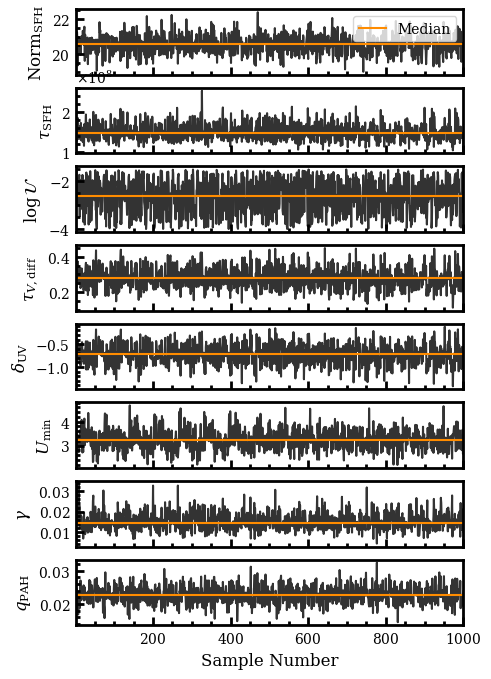

In [15]:
fig, axs = lgh.chain_plot(chain, color='black', alpha=0.8)

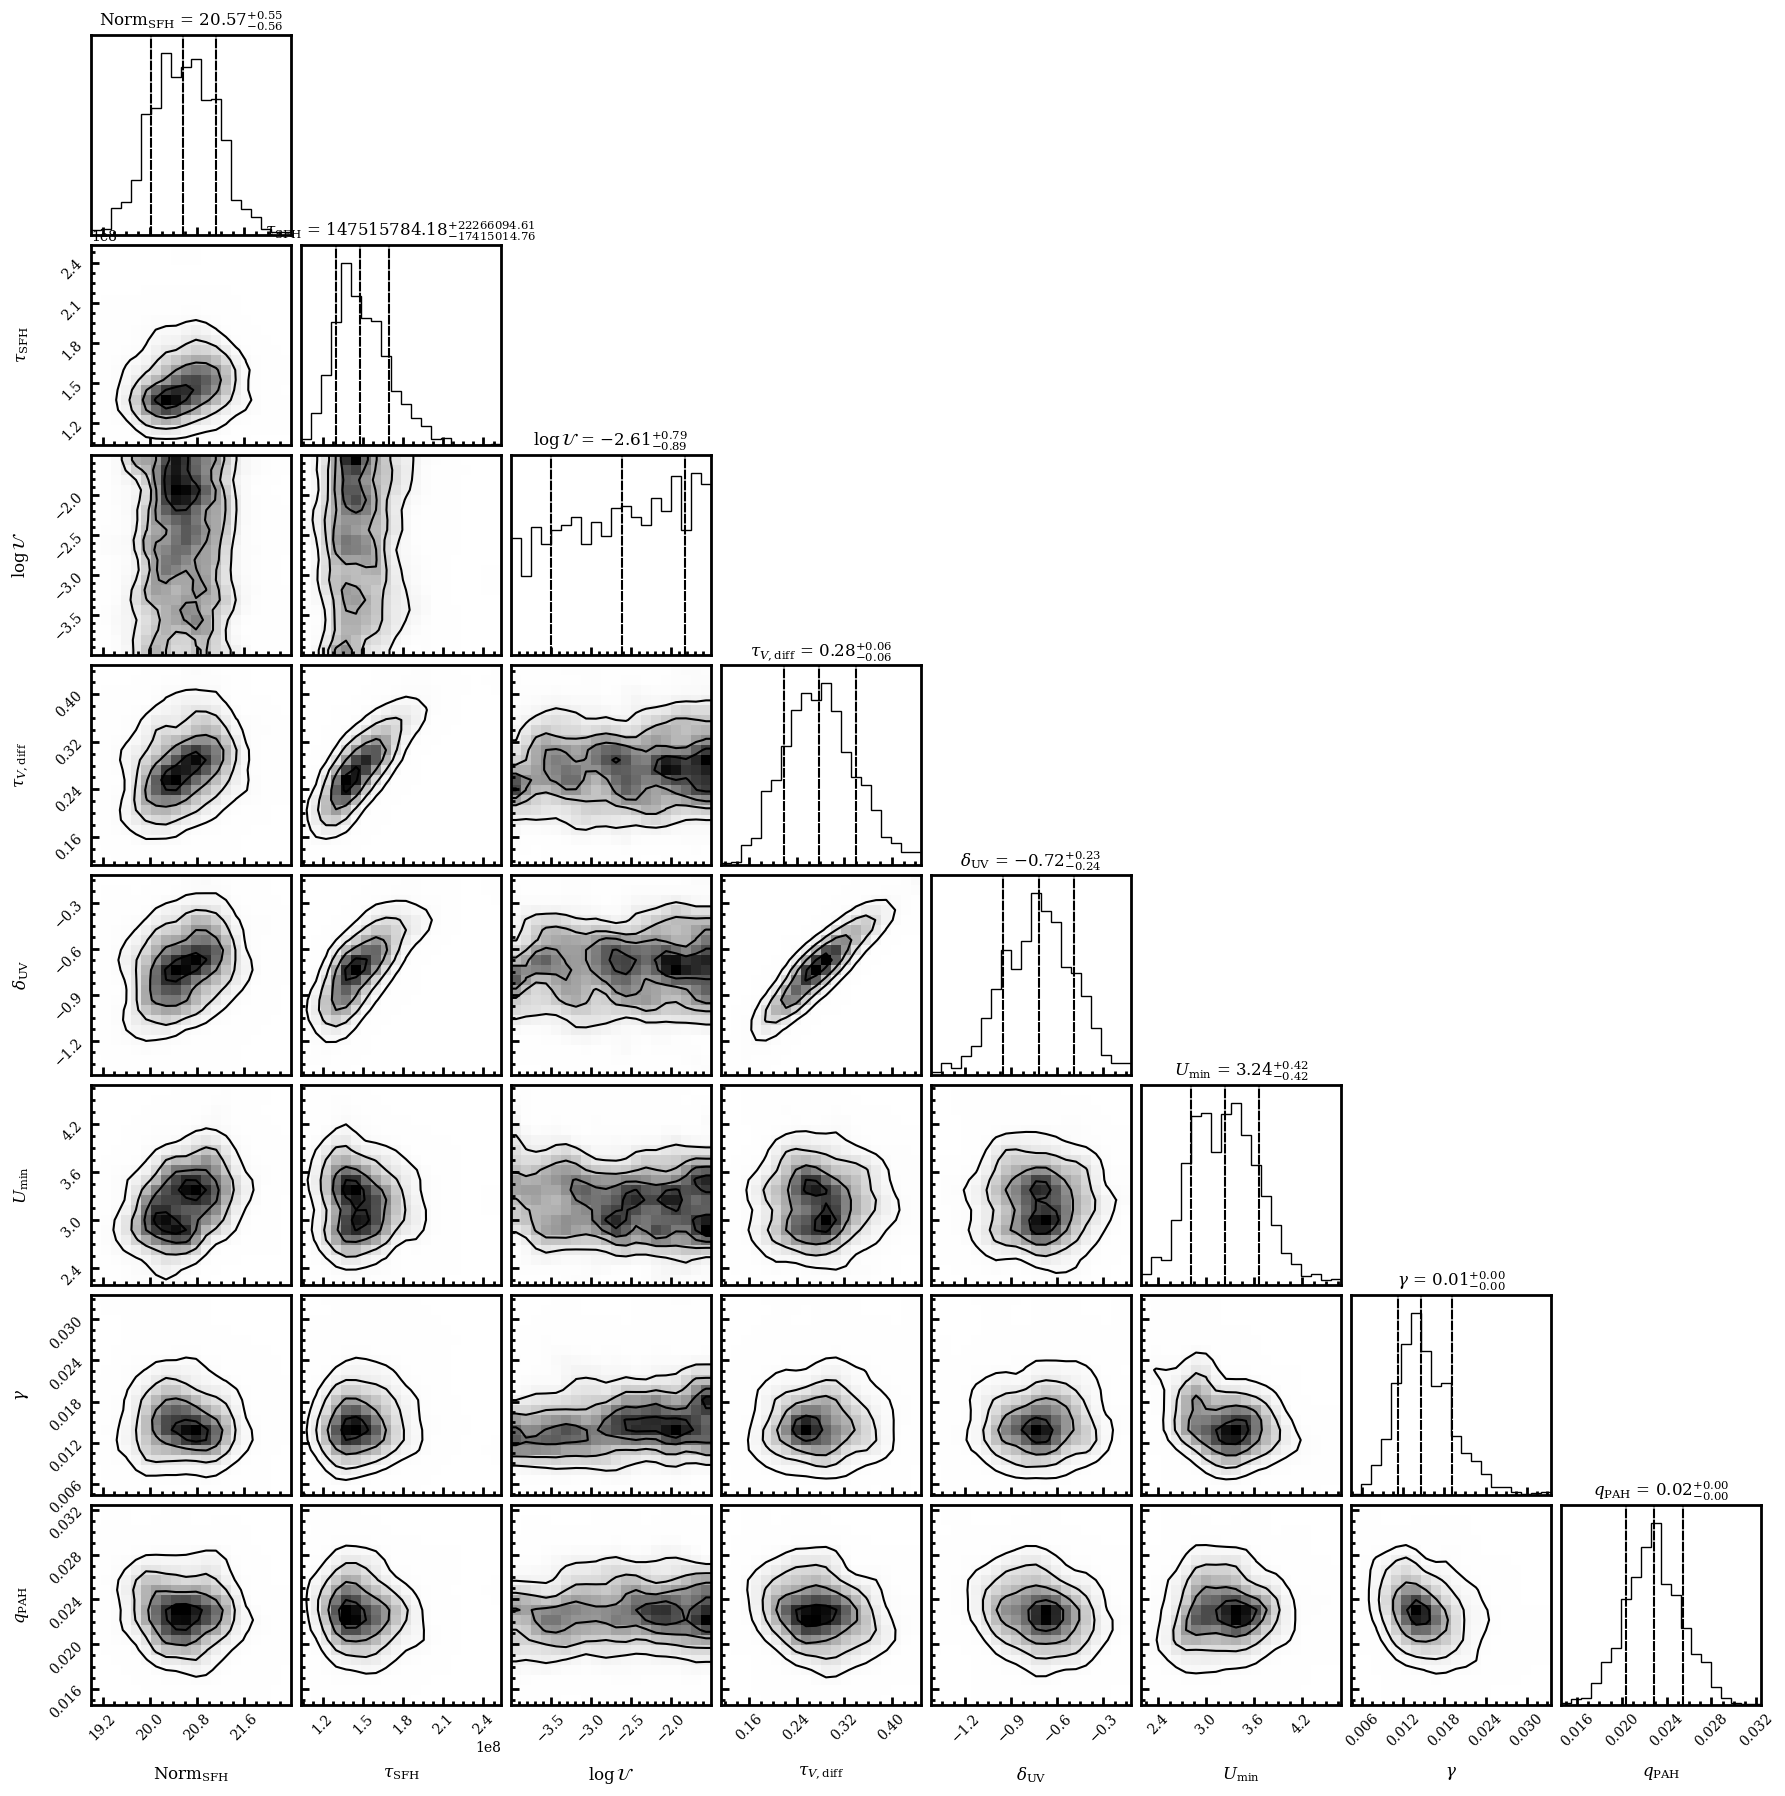

In [16]:
fig = lgh.corner_plot(chain, 
                    quantiles=(0.16, 0.50, 0.84),
                    smooth=1,
                    levels=None,
                    show_titles=True)

/opt/anaconda3/envs/ciao-4.17/lib/python3.11/site-packages/lightning/stellar/pegase.py:1070: RuntimeWarning: divide by zero encountered in log10
  np.log10(np.transpose(self.Lnu_obs, axes=[1,2,0,3])),


[1.00000000e-01 1.00771126e-01 1.01548199e-01 ... 9.84754044e+02
 9.92347744e+02 1.00000000e+03]


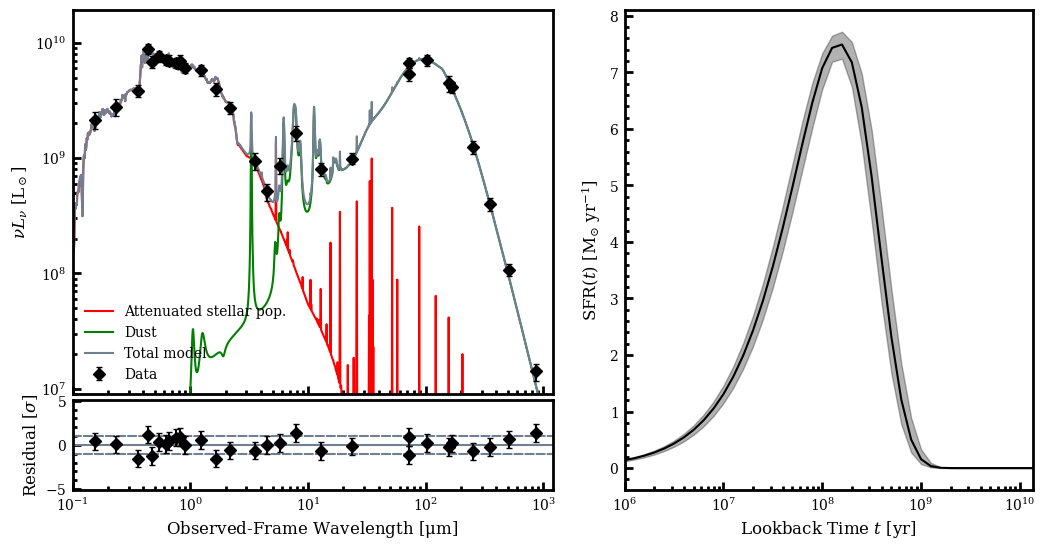

In [21]:
# Generate SED Figure with Fit and Residuals
fig4 = plt.figure(figsize=(12,6))
ax41 = fig4.add_axes([0.1, 0.26, 0.4, 0.64])
ax42 = fig4.add_axes([0.1, 0.1, 0.4, 0.15])
ax43 = fig4.add_axes([0.56, 0.1, 0.34, 0.8])

fig4, ax41 = lgh.sed_plot_bestfit(chain, logprob_chain,
                                plot_components=True,
                                ax=ax41,
                                legend_kwargs={'loc': 'lower left', 'frameon': False})
ax41.set_xticklabels([])
fig4, ax42 = lgh.sed_plot_delchi(chain, logprob_chain, ax=ax42)
fig4, ax43 = lgh.sfh_plot(chain, ax=ax43)

#lgh.__dir__()
print(lgh.wave_grid_obs)